In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn: preprocessing, model, evaluation, CV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

In [2]:
# Load preprocessed EEG data and labels saved from the feature extraction notebook
eeg = np.load("eeg_ml.npy")       # Shape: (1280, 32, 8064)
labels = np.load("labels_ml.npy") # Shape: (1280, 4)

print("EEG shape:", eeg.shape)
print("Labels shape:", labels.shape)

EEG shape: (1280, 32, 8064)
Labels shape: (1280, 4)


In [3]:
print(f"Total samples     : {eeg.shape[0]}")
print(f"EEG channels      : {eeg.shape[1]}")
print(f"Time points       : {eeg.shape[2]}")
print(f"Label dimensions  : {labels.shape[1]}")

# Valence is the first label column (index 0); scores range 1–9
valence = labels[:, 0]
print(f"\nValence — min: {valence.min()}, max: {valence.max()}, mean: {valence.mean():.2f}")

Total samples     : 1280
EEG channels      : 32
Time points       : 8064
Label dimensions  : 4

Valence — min: 1.0, max: 9.0, mean: 5.25


In [4]:
import numpy as np

print("Labels shape:", labels.shape)
print("Minimum of each label column:")
print(labels.min(axis=0))

print("\nMaximum of each label column:")
print(labels.max(axis=0))

print("\nFirst 10 labels:")
print(labels[:10])

Labels shape: (1280, 4)
Minimum of each label column:
[1. 1. 1. 1.]

Maximum of each label column:
[9. 9. 9. 9.]

First 10 labels:
[[7.71 7.6  6.9  7.83]
 [8.1  7.31 7.28 8.47]
 [8.58 7.54 9.   7.08]
 [4.94 6.01 6.12 8.06]
 [6.96 3.92 7.19 6.05]
 [8.27 3.92 7.   8.03]
 [7.44 3.73 7.08 7.04]
 [7.32 2.55 6.32 5.87]
 [4.04 3.29 3.62 5.99]
 [1.99 4.86 2.04 7.09]]


In [5]:
# Extract statistical features per channel: mean, std, variance
# Each sample: 32 channels × 3 features = 96-dimensional feature vector
features = []

for sample in eeg:
    mean_feat = np.mean(sample, axis=1)  # Shape: (32,)
    std_feat  = np.std(sample,  axis=1)  # Shape: (32,)
    var_feat  = np.var(sample,  axis=1)  # Shape: (32,)
    feature_vector = np.concatenate([mean_feat, std_feat, var_feat])
    features.append(feature_vector)

X = np.array(features)
print("Feature matrix shape:", X.shape)  # (1280, 96)

Feature matrix shape: (1280, 96)


In [6]:
# Define all four DEAP emotion dimensions and build binary labels for each
# Column order in `labels`: 0=Valence, 1=Arousal, 2=Dominance, 3=Liking
emotion_names = ["Valence", "Arousal", "Dominance", "Liking"]

y_dict = {}
for i, emotion in enumerate(emotion_names):
    y_dict[emotion] = (labels[:, i] > 5).astype(int)
    print(f"{emotion} — class distribution (0=Low, 1=High):", np.bincount(y_dict[emotion]))

Valence — class distribution (0=Low, 1=High): [572 708]
Arousal — class distribution (0=Low, 1=High): [543 737]
Dominance — class distribution (0=Low, 1=High): [500 780]
Liking — class distribution (0=Low, 1=High): [429 851]


In [7]:
import pickle
import numpy as np

all_labels = []

for i in range(1, 33):
    with open(f"s{i:02d}.dat", "rb") as f:
        data = pickle.load(f, encoding="latin1")
    all_labels.append(data["labels"])

all_labels = np.concatenate(all_labels, axis=0)

print(all_labels.shape)
print("Valence min/max:", all_labels[:,0].min(), all_labels[:,0].max())
print("Valence mean:", all_labels[:,0].mean())

print(">=5 :", np.sum(all_labels[:,0] >= 5))
print("<5  :", np.sum(all_labels[:,0] < 5))

(1280, 4)
Valence min/max: 1.0 9.0
Valence mean: 5.2543125
>=5 : 724
<5  : 556


In [8]:
def train_evaluate_full_model(emotion_name, X, y):
    """
    Train/evaluate a Random Forest on ALL 32 channels (96 Mean/Std/Var features)
    for a single emotion. Returns model, scaler, metrics, CV scores, and a
    channel importance ranking correctly mapped to the block feature layout
    produced by the Mean/Std/Var extraction above.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f"\n{'='*60}\n  {emotion_name} — Full 32-Channel Model\n{'='*60}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=[f"Low {emotion_name}", f"High {emotion_name}"]
    ))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_model = RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
    )
    cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring="accuracy")
    print(f"\nCV Fold Scores : {np.round(cv_scores, 4)}")
    print(f"CV Mean Accuracy : {cv_scores.mean():.4f}")
    print(f"CV Std Deviation : {cv_scores.std():.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Low {emotion_name}", f"High {emotion_name}"],
        yticklabels=[f"Low {emotion_name}", f"High {emotion_name}"]
    )
    plt.title(f"{emotion_name} — Confusion Matrix (32 Channels)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_confusion_matrix.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(range(1, 6), cv_scores * 100, color="steelblue", edgecolor="black")
    plt.axhline(cv_scores.mean() * 100, color="red", linestyle="--",
                label=f"Mean: {cv_scores.mean()*100:.2f}%")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{emotion_name} — 5-Fold Cross-Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_cv_scores.png", dpi=150)
    plt.show()

    # Feature names correctly mapped to the BLOCK layout: [mean_ch1..32, std_ch1..32, var_ch1..32]
    n_channels = X.shape[1] // 3
    feature_names = (
        [f"Ch{ch}_Mean" for ch in range(1, n_channels + 1)] +
        [f"Ch{ch}_Std"  for ch in range(1, n_channels + 1)] +
        [f"Ch{ch}_Var"  for ch in range(1, n_channels + 1)]
    )

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"{emotion_name} — Top 20 Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_feature_importances.png", dpi=150)
    plt.show()

    # Channel importance: sum Mean+Std+Var per channel (correct block indices)
    channel_scores = {}
    for ch in range(n_channels):
        idx_mean, idx_std, idx_var = ch, n_channels + ch, 2 * n_channels + ch
        score = (
            model.feature_importances_[idx_mean] +
            model.feature_importances_[idx_std] +
            model.feature_importances_[idx_var]
        )
        channel_scores[f"Channel_{ch + 1}"] = score

    channel_ranking = pd.DataFrame(
        channel_scores.items(), columns=["Channel", "Score"]
    ).sort_values("Score", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(14, 5))
    sns.barplot(
        data=channel_ranking, x="Channel", y="Score",
        order=channel_ranking["Channel"], palette="coolwarm"
    )
    plt.xticks(rotation=90)
    plt.xlabel("EEG Channel")
    plt.ylabel("Total Importance Score")
    plt.title(f"{emotion_name} — EEG Channel Importance Ranking (All {n_channels} Channels)")
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_channel_importance.png", dpi=150)
    plt.show()

    return {
        "model": model, "scaler": scaler,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "channel_ranking": channel_ranking,
    }

In [9]:
def extract_features(eeg_data):
    """
    Extract Mean, Std, Variance per channel for each EEG sample.

    Parameters:
        eeg_data (np.ndarray): Shape (n_samples, n_channels, n_timepoints)

    Returns:
        np.ndarray: Feature matrix of shape (n_samples, n_channels * 3)
    """
    features = []
    for sample in eeg_data:
        mean_feat = np.mean(sample, axis=1)
        std_feat  = np.std(sample,  axis=1)
        var_feat  = np.var(sample,  axis=1)
        features.append(np.concatenate([mean_feat, std_feat, var_feat]))
    return np.array(features)

In [10]:
def channel_reduction_pipeline(emotion_name, eeg, y, channel_ranking):
    """
    Retrain/evaluate using top 32/16/8/4 ranked channels (Mean/Std/Var features only).
    """
    ranked_channel_nums = (
        channel_ranking["Channel"].str.extract(r"(\d+)").astype(int)[0].tolist()
    )
    top32_idx = [c - 1 for c in ranked_channel_nums[:32]]
    top16_idx = [c - 1 for c in ranked_channel_nums[:16]]
    top8_idx  = [c - 1 for c in ranked_channel_nums[:8]]
    top4_idx  = [c - 1 for c in ranked_channel_nums[:4]]

    configs = {
        "Top 32 Channels": top32_idx,
        "Top 16 Channels": top16_idx,
        "Top 8 Channels" : top8_idx,
        "Top 4 Channels" : top4_idx,
    }

    results = []
    trained = {}

    for config_name, ch_idx in configs.items():
        eeg_subset = eeg[:, ch_idx, :]
        X_sub = extract_features(eeg_subset)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y, test_size=0.2, random_state=42, stratify=y
        )
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        clf = RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
        )
        clf.fit(X_tr, y_tr)
        y_pred_sub = clf.predict(X_te)

        acc  = accuracy_score(y_te, y_pred_sub)
        prec = precision_score(y_te, y_pred_sub)
        rec  = recall_score(y_te, y_pred_sub)
        f1   = f1_score(y_te, y_pred_sub)

        cv_scores = cross_val_score(
            RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                    random_state=42, n_jobs=-1),
            X_sub, y,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring="accuracy"
        )

        results.append({
            "Emotion": emotion_name,
            "Configuration": config_name,
            "Channels": len(ch_idx),
            "Features": len(ch_idx) * 3,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4),
            "CV Mean Acc": round(cv_scores.mean(), 4),
            "CV Std": round(cv_scores.std(), 4),
        })

        trained[config_name] = {
            "ch_idx": ch_idx, "model": clf, "scaler": sc,
            "y_te": y_te, "y_pred": y_pred_sub,
        }

        print(f"\n{'='*50}\n  {emotion_name} — {config_name}\n{'='*50}")
        print(f"  Accuracy  : {acc:.4f}")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print(f"  CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print("\n  Classification Report:")
        print(classification_report(
            y_te, y_pred_sub,
            target_names=[f"Low {emotion_name}", f"High {emotion_name}"]
        ))

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    channel_counts = [r["Channels"] for r in results]
    accuracies     = [r["Accuracy"] for r in results]
    cv_means       = [r["CV Mean Acc"] for r in results]
    cv_stds        = [r["CV Std"] for r in results]

    axes[0].plot(channel_counts, accuracies, marker="o", color="steelblue", linewidth=2)
    for x, yv in zip(channel_counts, accuracies):
        axes[0].annotate(f"{yv:.4f}", (x, yv), textcoords="offset points", xytext=(0, 8), ha="center")
    axes[0].set_xlabel("Number of Channels")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{emotion_name} — Hold-out Test Accuracy vs Channels")
    axes[0].set_xticks(channel_counts)
    axes[0].grid(True)

    axes[1].errorbar(channel_counts, cv_means, yerr=cv_stds, marker="o", color="darkorange",
                      capsize=5, linewidth=2, elinewidth=1.5)
    for x, yv in zip(channel_counts, cv_means):
        axes[1].annotate(f"{yv:.4f}", (x, yv), textcoords="offset points", xytext=(0, 8), ha="center")
    axes[1].set_xlabel("Number of Channels")
    axes[1].set_ylabel("CV Mean Accuracy")
    axes[1].set_title(f"{emotion_name} — 5-Fold CV Accuracy vs Channels")
    axes[1].set_xticks(channel_counts)
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_accuracy_vs_channels.png", dpi=150)
    plt.show()

    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
    x = np.arange(len(results))
    width = 0.2
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, metric in enumerate(metrics):
        values = [r[metric] for r in results]
        bars = ax.bar(x + i * width, values, width, label=metric)
        ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)
    ax.set_xlabel("Channel Configuration")
    ax.set_ylabel("Score")
    ax.set_title(f"{emotion_name} — Evaluation Metrics Across Channel Configurations")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([r["Configuration"] for r in results])
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_metrics_comparison.png", dpi=150)
    plt.show()

    fig, cm_axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, config_name in zip(cm_axes, configs.keys()):
        t = trained[config_name]
        cm = confusion_matrix(t["y_te"], t["y_pred"])
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Low", "High"], yticklabels=["Low", "High"]
        )
        ax.set_title(config_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle(f"{emotion_name} — Confusion Matrices Across Channel Configurations",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{emotion_name.lower()}_confusion_matrices_all.png", dpi=150)
    plt.show()

    return results, results_df, configs, trained

In [11]:
def save_best_model(emotion_name, results, configs, trained):
    """
    Pick the channel configuration with highest CV Mean Accuracy, retrain on
    the FULL dataset with those channels, and save model + scaler + channels.
    """
    best = max(results, key=lambda r: r["CV Mean Acc"])
    best_config_name = best["Configuration"]
    best_ch_idx = configs[best_config_name]

    print(f"\nBest configuration for {emotion_name}: {best_config_name}")
    print(f"CV Mean Accuracy : {best['CV Mean Acc']:.4f} ± {best['CV Std']:.4f}")

    y_full = y_dict[emotion_name]
    eeg_best = eeg[:, best_ch_idx, :]
    X_best   = extract_features(eeg_best)
    sc_best  = StandardScaler()
    X_best   = sc_best.fit_transform(X_best)

    best_model = RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
    )
    best_model.fit(X_best, y_full)

    tag = emotion_name.lower()
    model_path  = f"{tag}_mean_var_model.pkl"
    scaler_path = f"{tag}_mean_var_scaler.pkl"

    joblib.dump(best_model, model_path)
    joblib.dump(sc_best, scaler_path)

    selected_channels = [c + 1 for c in best_ch_idx]
    print(f"Saved → {model_path}")
    print(f"Saved → {scaler_path}")
    print(f"Selected channels ({len(selected_channels)}): {selected_channels}")

    return {
        "Emotion": emotion_name,
        "Best Configuration": best_config_name,
        "Channels": len(selected_channels),
        "Selected Channels": selected_channels,
        "Model Path": model_path,
        "Scaler Path": scaler_path,
    }


  Valence — Full 32-Channel Model
Accuracy  : 0.5664
Precision : 0.5963
Recall    : 0.6761
F1-Score  : 0.6337

Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.52      0.43      0.47       114
High Valence       0.60      0.68      0.63       142

    accuracy                           0.57       256
   macro avg       0.56      0.55      0.55       256
weighted avg       0.56      0.57      0.56       256

Confusion Matrix:
[[49 65]
 [46 96]]

CV Fold Scores : [0.6094 0.5742 0.5977 0.582  0.6484]
CV Mean Accuracy : 0.6023
CV Std Deviation : 0.0261


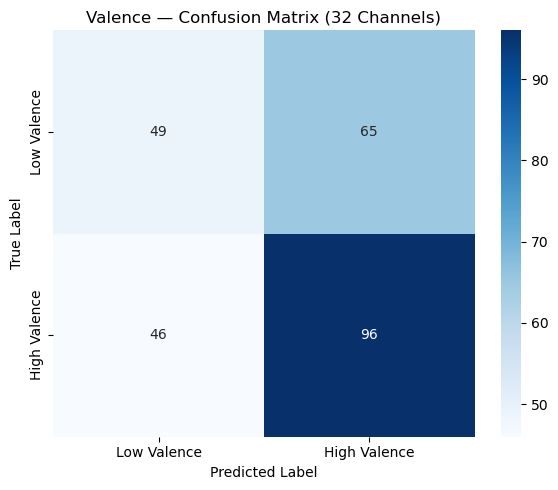

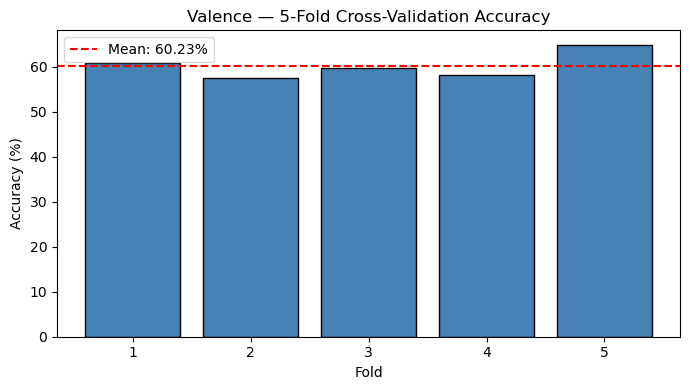

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


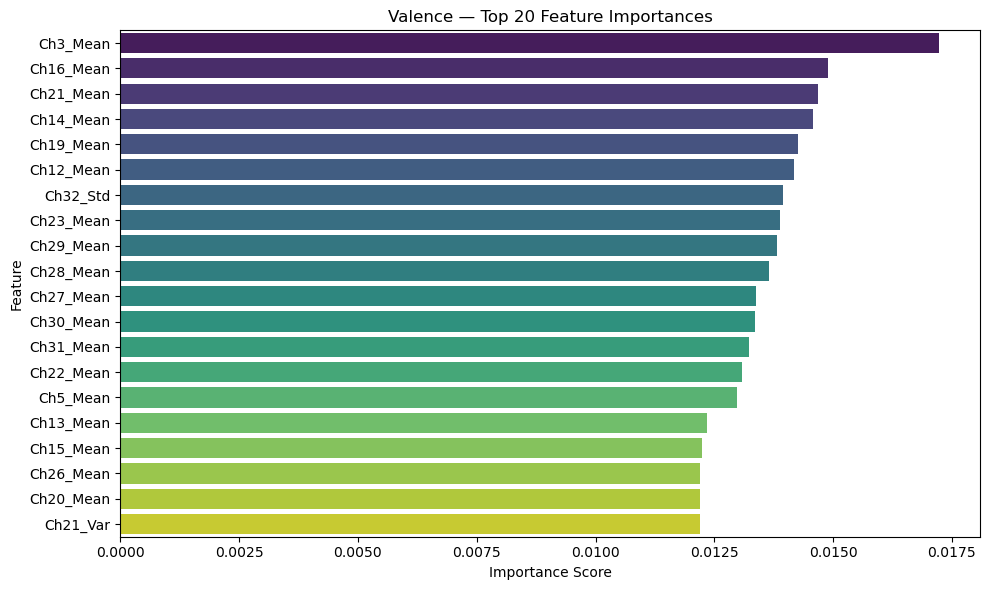

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


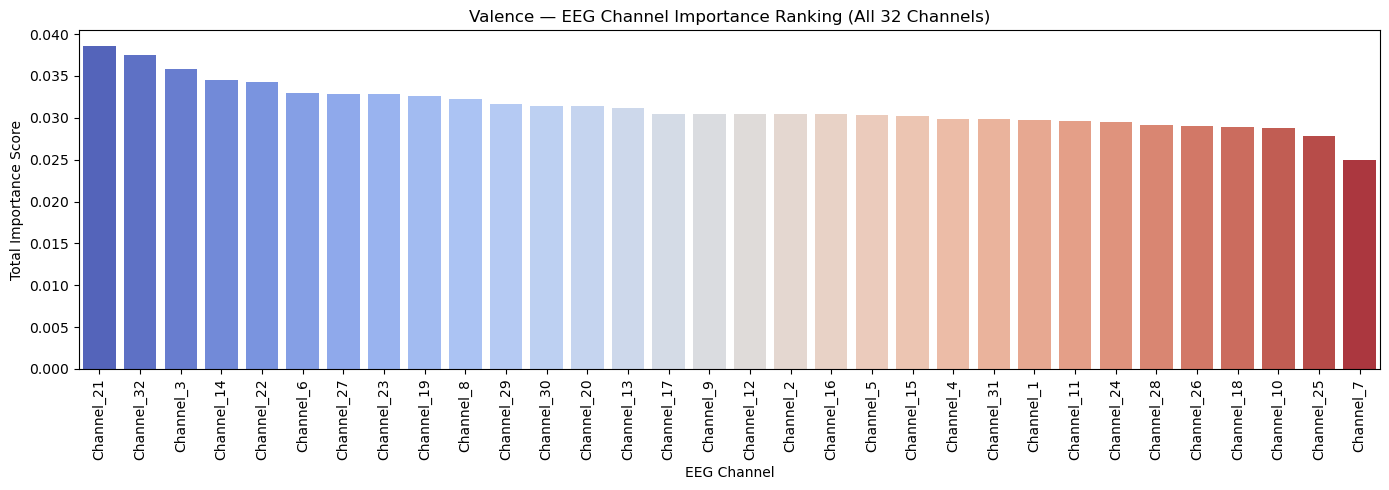


  Valence — Top 32 Channels
  Accuracy  : 0.5859
  Precision : 0.6047
  Recall    : 0.7324
  F1-Score  : 0.6624
  CV Accuracy: 0.5953 ± 0.0163

  Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.55      0.40      0.46       114
High Valence       0.60      0.73      0.66       142

    accuracy                           0.59       256
   macro avg       0.58      0.57      0.56       256
weighted avg       0.58      0.59      0.57       256


  Valence — Top 16 Channels
  Accuracy  : 0.5781
  Precision : 0.6012
  Recall    : 0.7113
  F1-Score  : 0.6516
  CV Accuracy: 0.6039 ± 0.0179

  Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.53      0.41      0.47       114
High Valence       0.60      0.71      0.65       142

    accuracy                           0.58       256
   macro avg       0.57      0.56      0.56       256
weighted avg       0.57      0.58      0.57       256


  Val

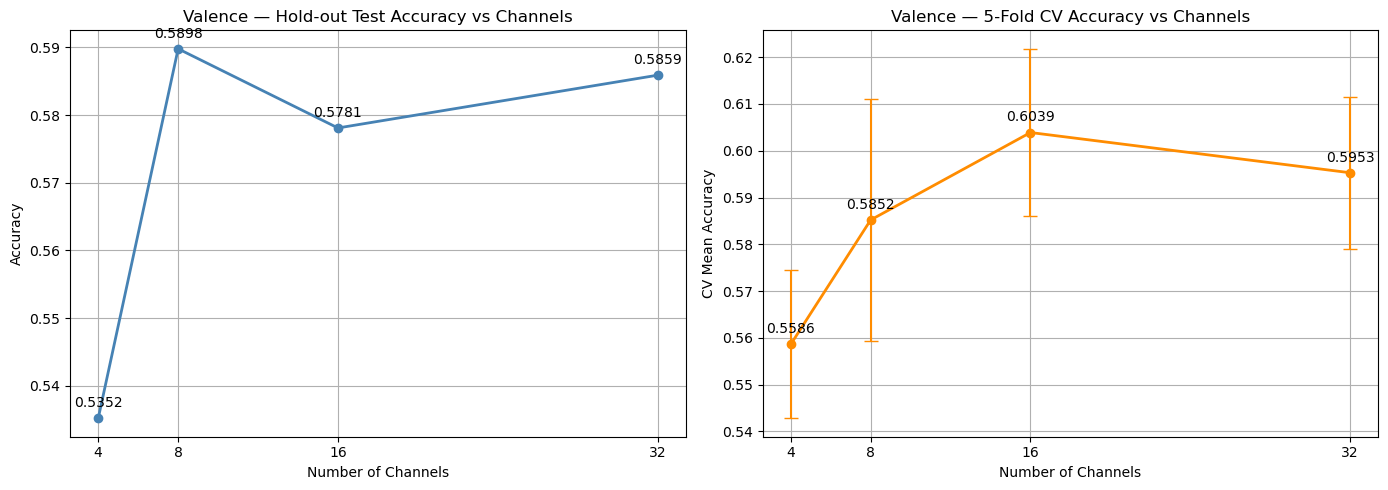

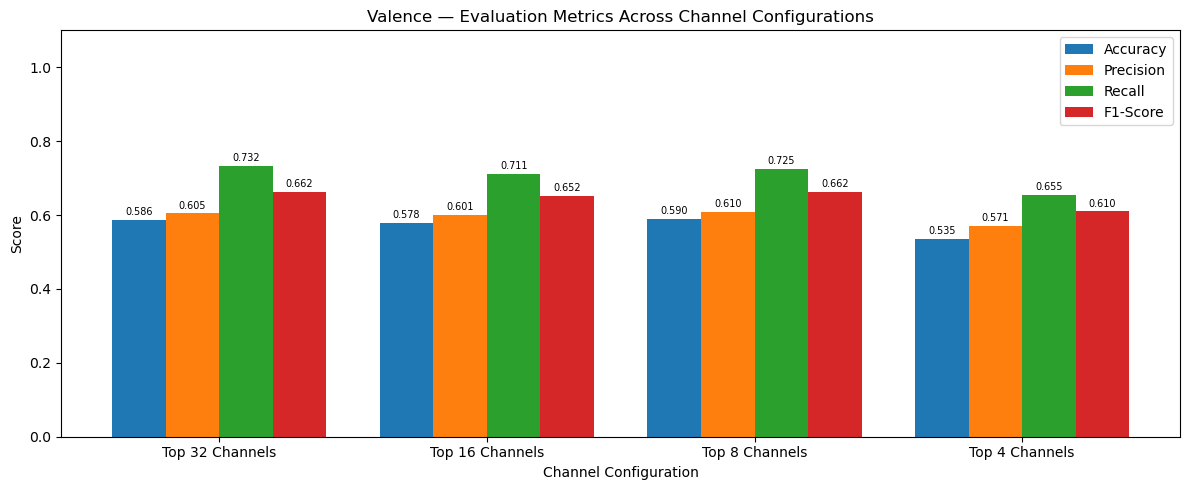

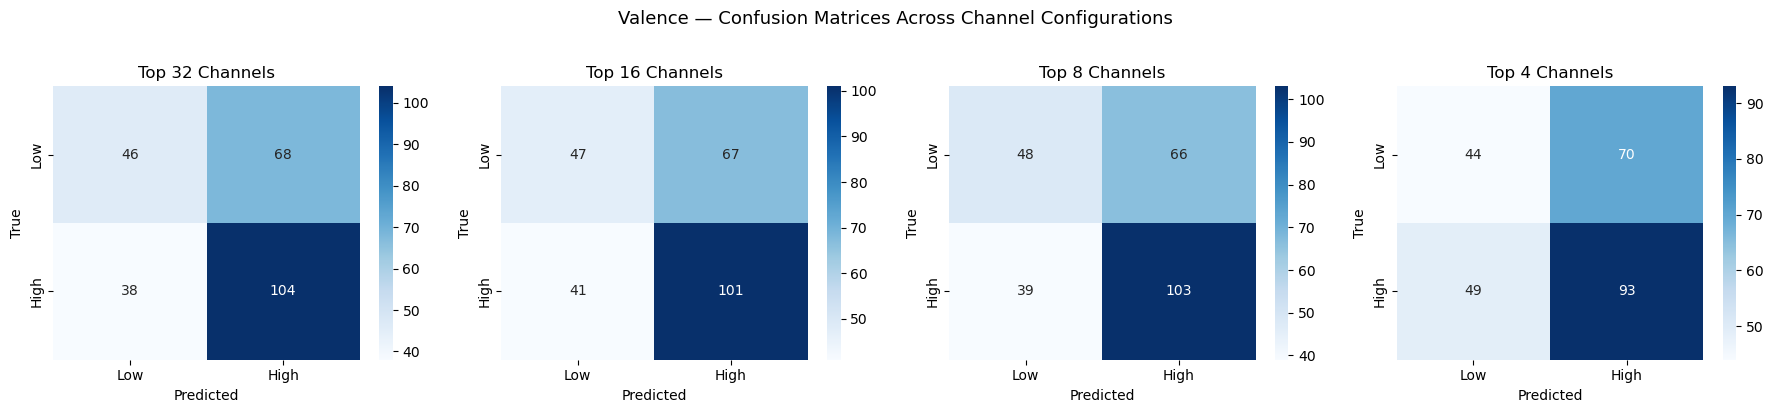


Best configuration for Valence: Top 16 Channels
CV Mean Accuracy : 0.6039 ± 0.0179
Saved → valence_mean_var_model.pkl
Saved → valence_mean_var_scaler.pkl
Selected channels (16): [21, 32, 3, 14, 22, 6, 27, 23, 19, 8, 29, 30, 20, 13, 17, 9]

  Arousal — Full 32-Channel Model
Accuracy  : 0.5742
Precision : 0.6188
Recall    : 0.6735
F1-Score  : 0.6450

Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.50      0.44      0.47       109
High Arousal       0.62      0.67      0.64       147

    accuracy                           0.57       256
   macro avg       0.56      0.56      0.56       256
weighted avg       0.57      0.57      0.57       256

Confusion Matrix:
[[48 61]
 [48 99]]

CV Fold Scores : [0.6484 0.6523 0.582  0.5977 0.5859]
CV Mean Accuracy : 0.6133
CV Std Deviation : 0.0308


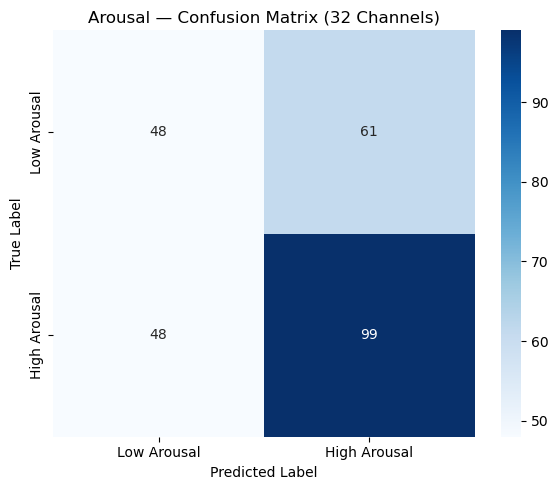

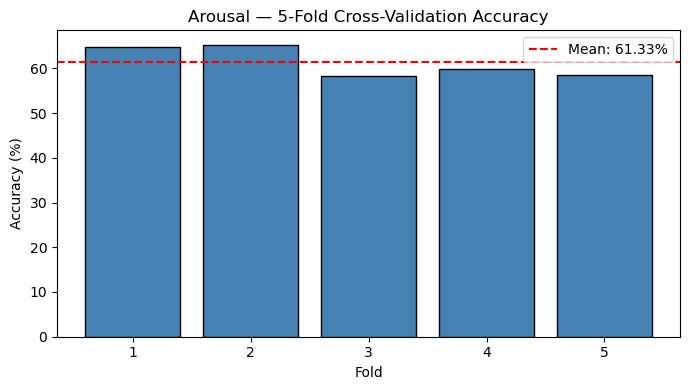

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


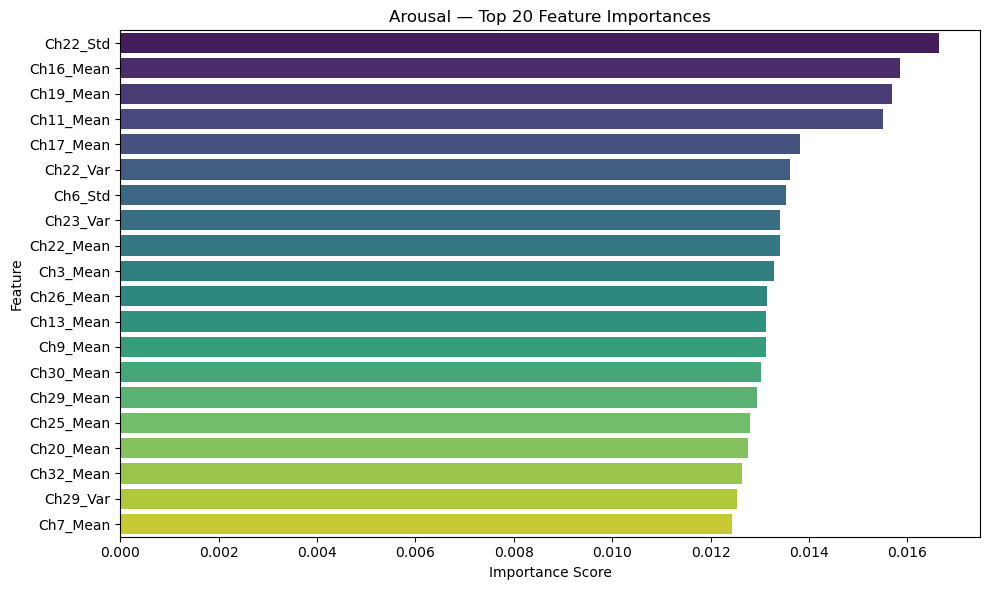

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


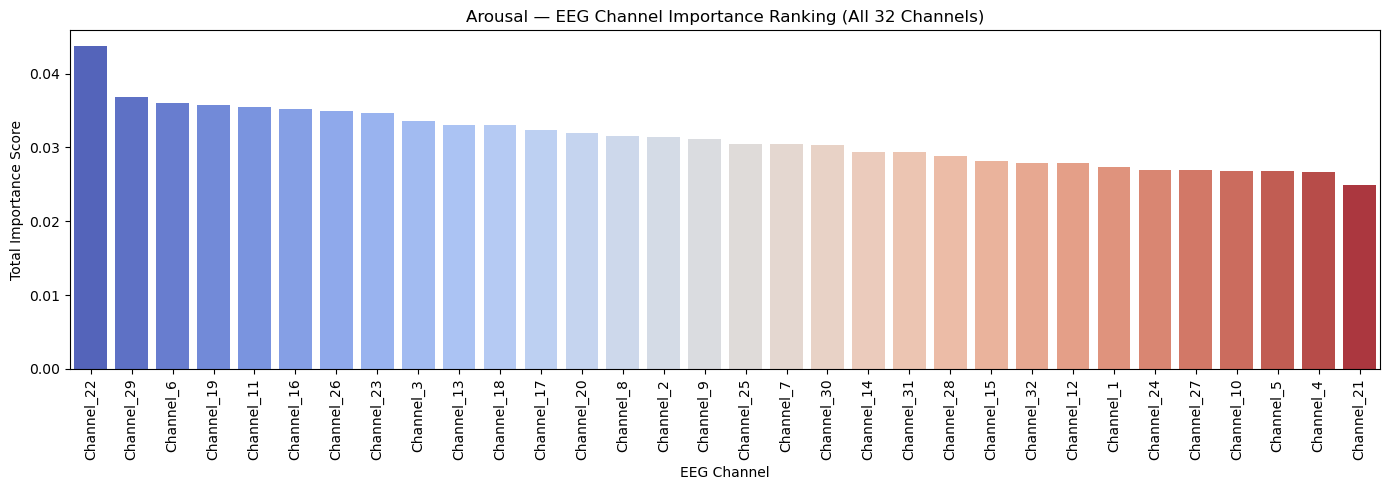


  Arousal — Top 32 Channels
  Accuracy  : 0.5586
  Precision : 0.6062
  Recall    : 0.6599
  F1-Score  : 0.6319
  CV Accuracy: 0.6148 ± 0.0403

  Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.48      0.42      0.45       109
High Arousal       0.61      0.66      0.63       147

    accuracy                           0.56       256
   macro avg       0.54      0.54      0.54       256
weighted avg       0.55      0.56      0.55       256


  Arousal — Top 16 Channels
  Accuracy  : 0.5703
  Precision : 0.6135
  Recall    : 0.6803
  F1-Score  : 0.6452
  CV Accuracy: 0.6109 ± 0.0245

  Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.49      0.42      0.46       109
High Arousal       0.61      0.68      0.65       147

    accuracy                           0.57       256
   macro avg       0.55      0.55      0.55       256
weighted avg       0.56      0.57      0.56       256


  Aro

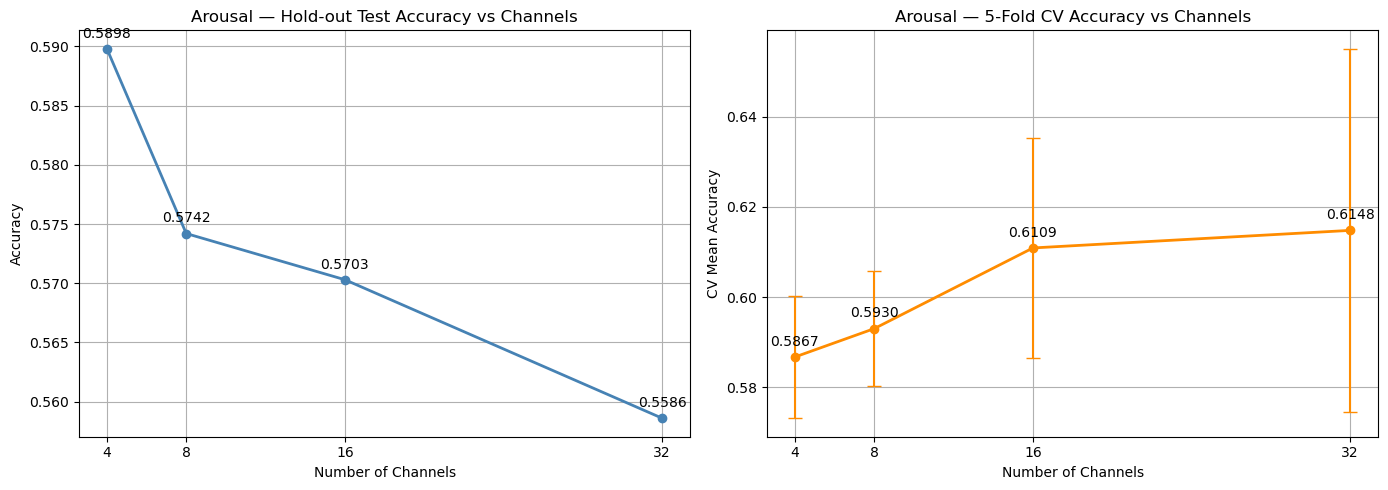

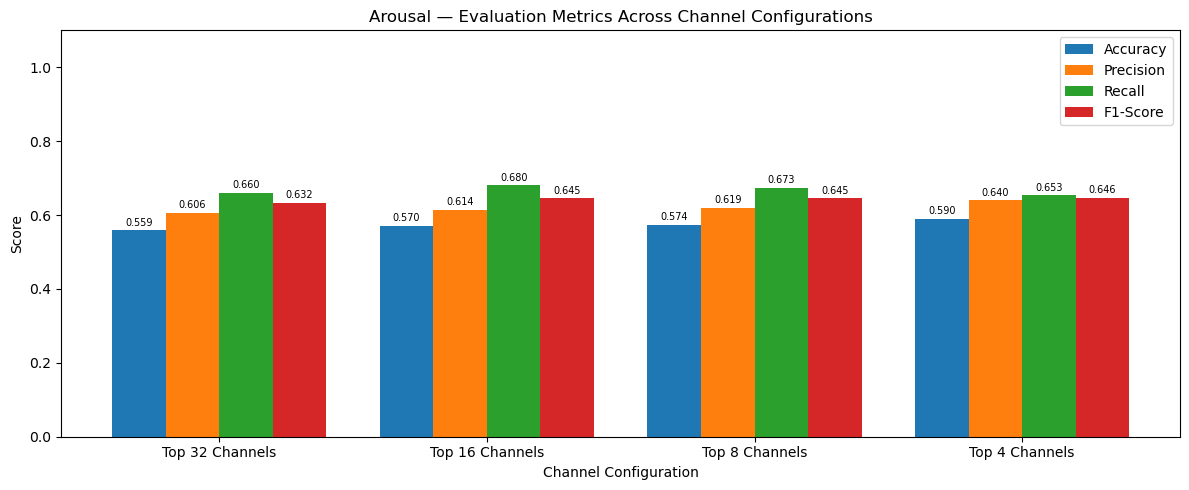

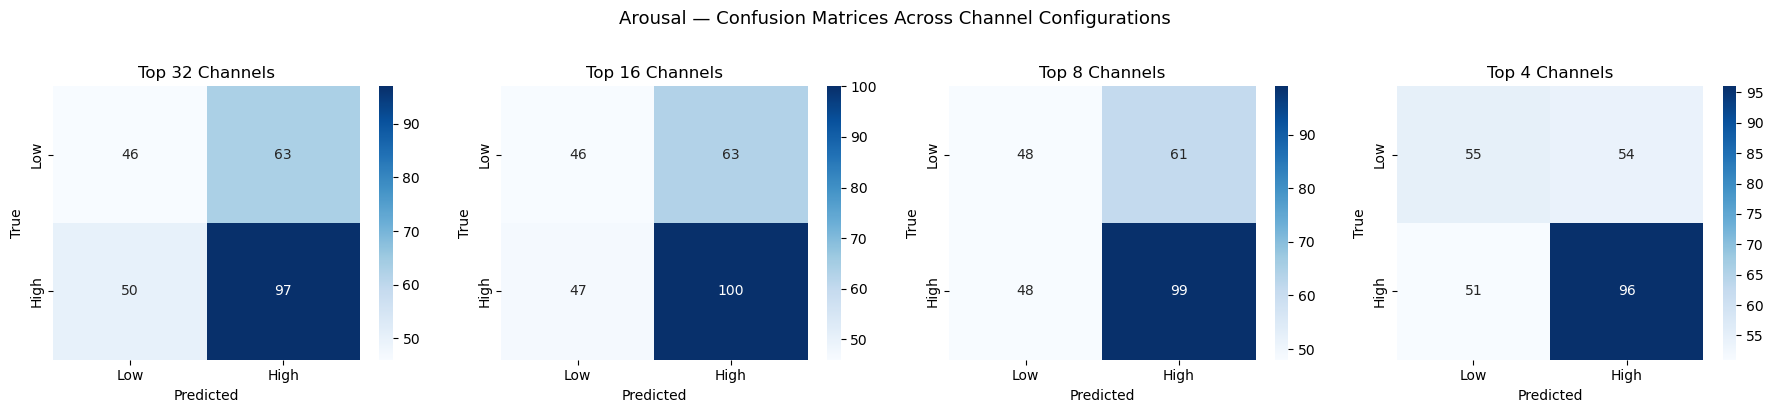


Best configuration for Arousal: Top 32 Channels
CV Mean Accuracy : 0.6148 ± 0.0403
Saved → arousal_mean_var_model.pkl
Saved → arousal_mean_var_scaler.pkl
Selected channels (32): [22, 29, 6, 19, 11, 16, 26, 23, 3, 13, 18, 17, 20, 8, 2, 9, 25, 7, 30, 14, 31, 28, 15, 32, 12, 1, 24, 27, 10, 5, 4, 21]

  Dominance — Full 32-Channel Model
Accuracy  : 0.6445
Precision : 0.6738
Recall    : 0.8077
F1-Score  : 0.7347

Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.57      0.39      0.46       100
High Dominance       0.67      0.81      0.73       156

      accuracy                           0.64       256
     macro avg       0.62      0.60      0.60       256
  weighted avg       0.63      0.64      0.63       256

Confusion Matrix:
[[ 39  61]
 [ 30 126]]

CV Fold Scores : [0.6328 0.6484 0.6523 0.6523 0.6367]
CV Mean Accuracy : 0.6445
CV Std Deviation : 0.0082


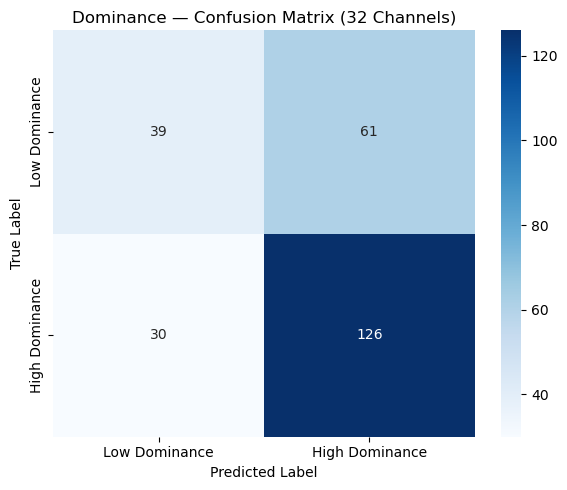

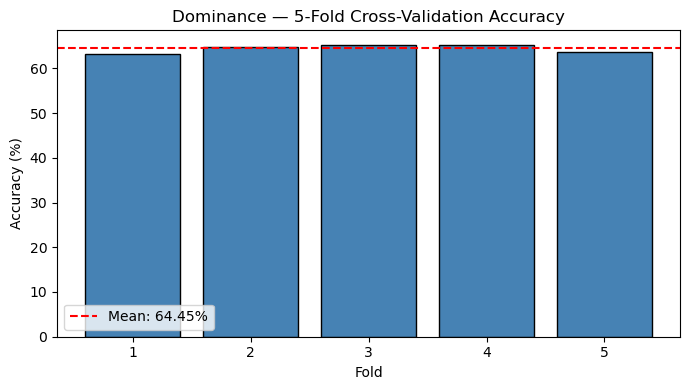

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


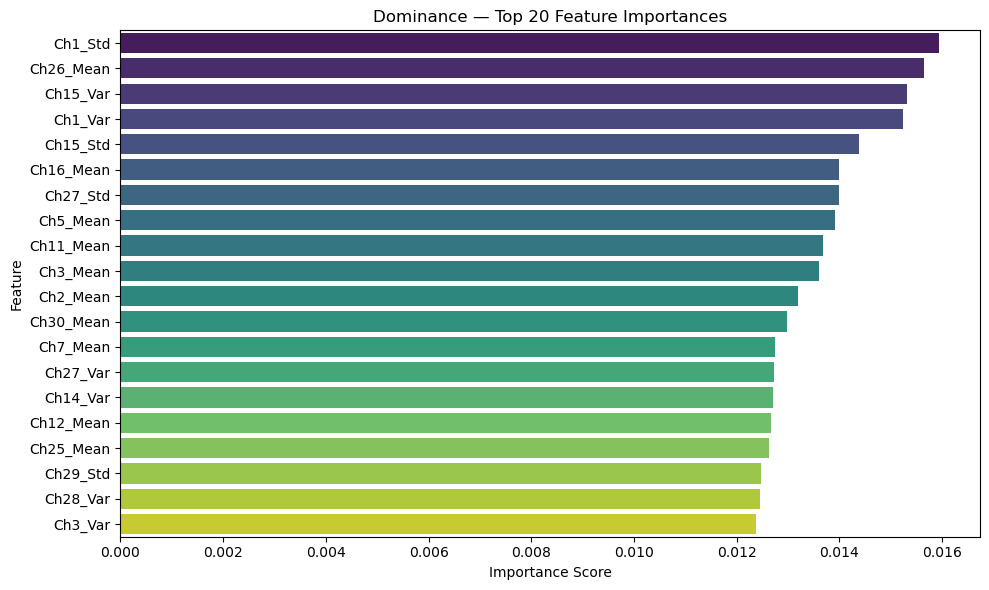

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


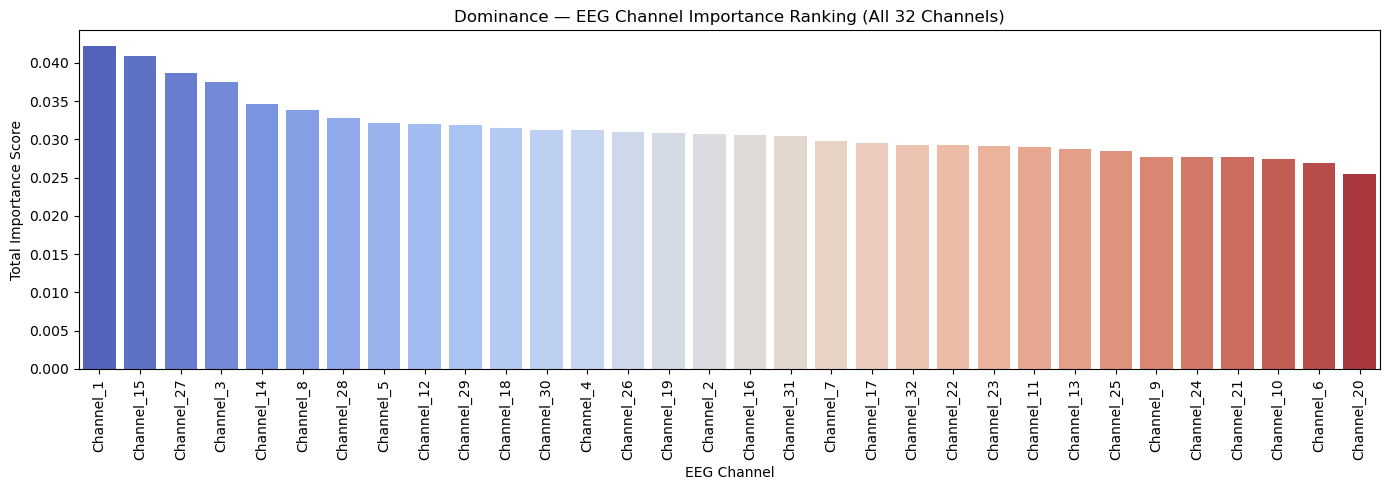


  Dominance — Top 32 Channels
  Accuracy  : 0.6445
  Precision : 0.6684
  Recall    : 0.8269
  F1-Score  : 0.7393
  CV Accuracy: 0.6383 ± 0.0120

  Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.57      0.36      0.44       100
High Dominance       0.67      0.83      0.74       156

      accuracy                           0.64       256
     macro avg       0.62      0.59      0.59       256
  weighted avg       0.63      0.64      0.62       256


  Dominance — Top 16 Channels
  Accuracy  : 0.6328
  Precision : 0.6649
  Recall    : 0.8013
  F1-Score  : 0.7267
  CV Accuracy: 0.6312 ± 0.0169

  Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.54      0.37      0.44       100
High Dominance       0.66      0.80      0.73       156

      accuracy                           0.63       256
     macro avg       0.60      0.59      0.58       256
  weighted avg       0.62      0.63

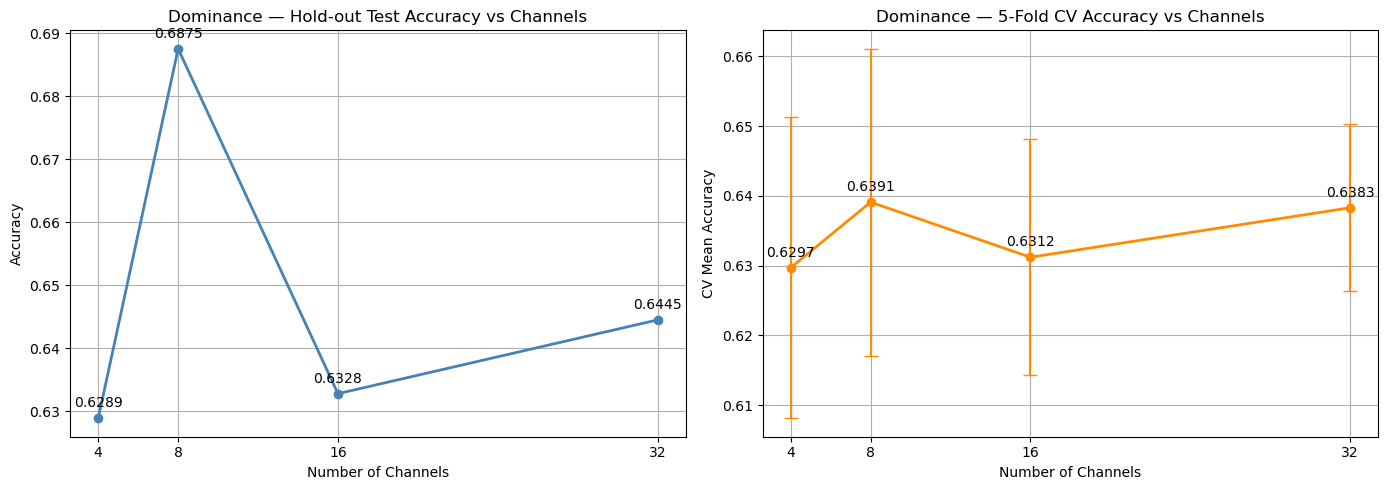

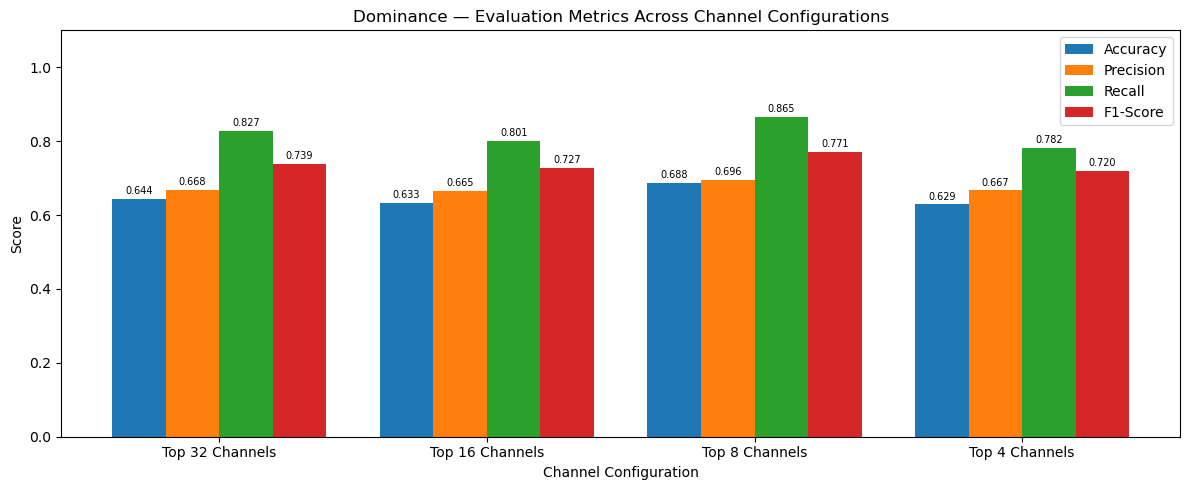

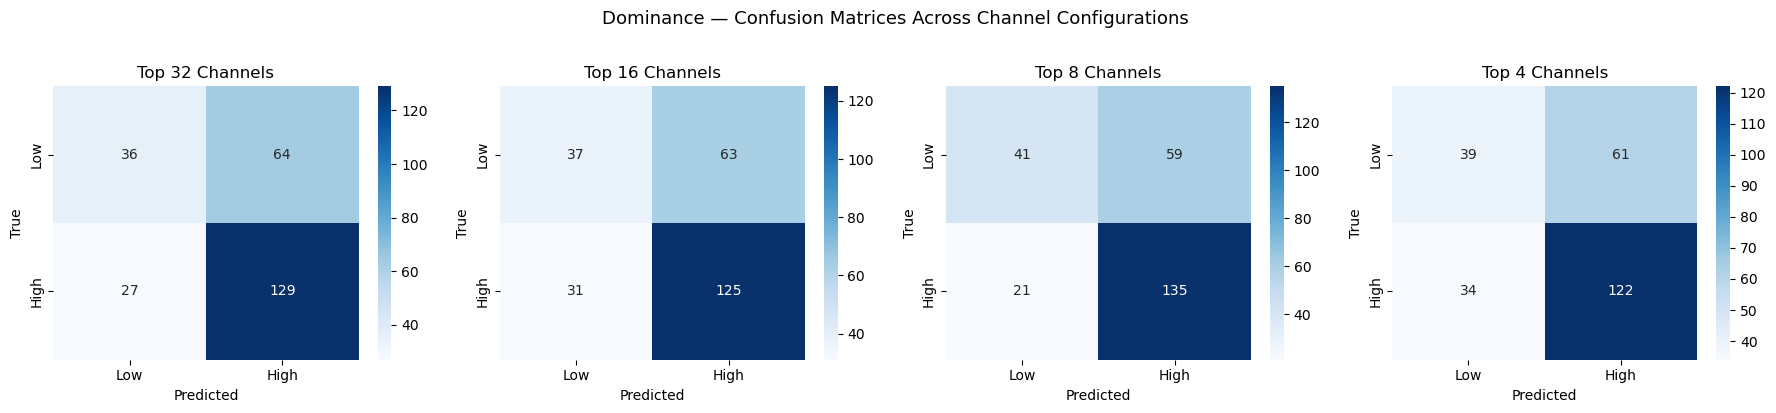


Best configuration for Dominance: Top 8 Channels
CV Mean Accuracy : 0.6391 ± 0.0220
Saved → dominance_mean_var_model.pkl
Saved → dominance_mean_var_scaler.pkl
Selected channels (8): [1, 15, 27, 3, 14, 8, 28, 5]

  Liking — Full 32-Channel Model
Accuracy  : 0.6758
Precision : 0.6968
Recall    : 0.9059
F1-Score  : 0.7877

Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.54      0.22      0.31        86
 High Liking       0.70      0.91      0.79       170

    accuracy                           0.68       256
   macro avg       0.62      0.56      0.55       256
weighted avg       0.65      0.68      0.63       256

Confusion Matrix:
[[ 19  67]
 [ 16 154]]

CV Fold Scores : [0.6367 0.6328 0.6406 0.6367 0.668 ]
CV Mean Accuracy : 0.6430
CV Std Deviation : 0.0127


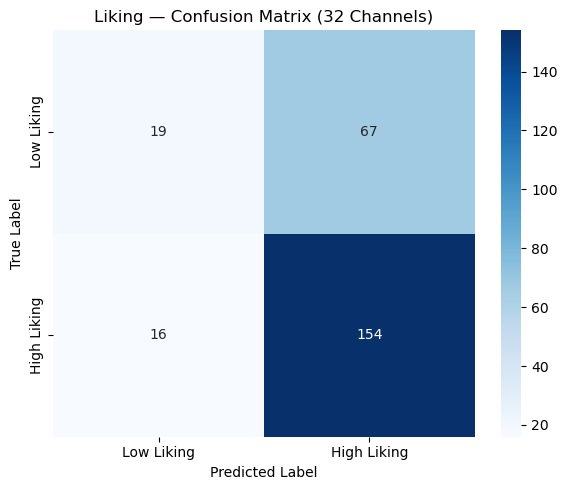

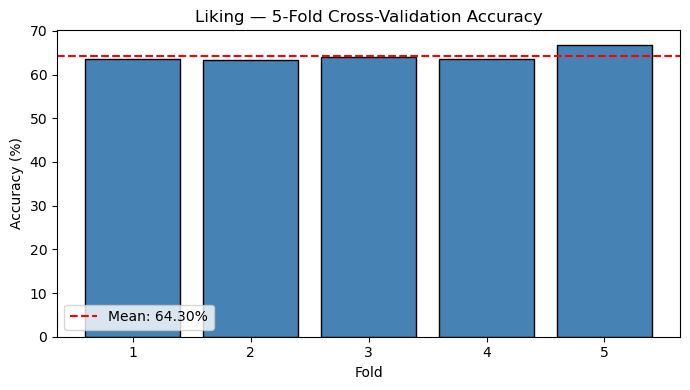

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


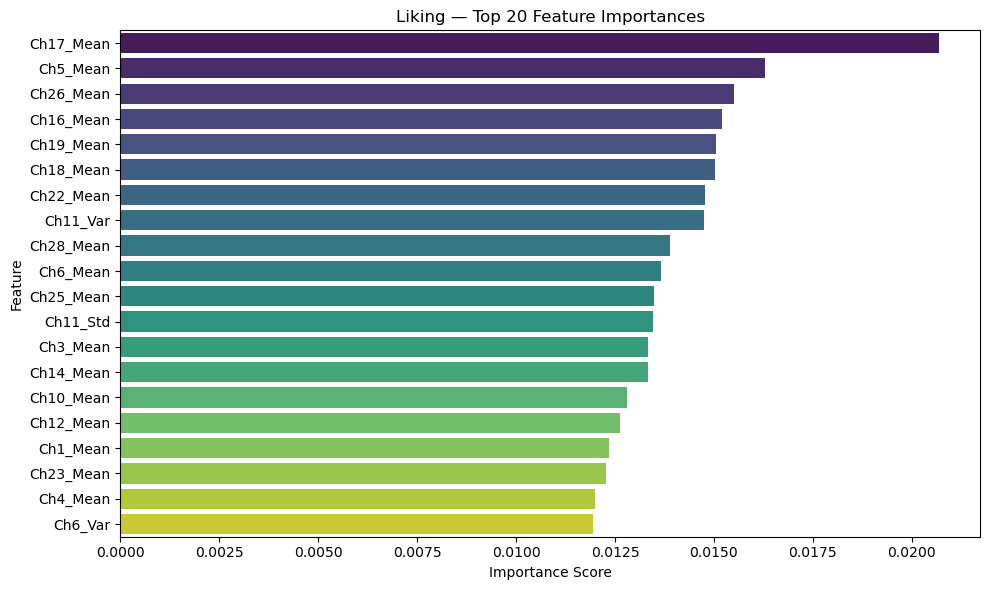

C:\Users\Sayantan\AppData\Local\Temp\ipykernel_13656\2379544668.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


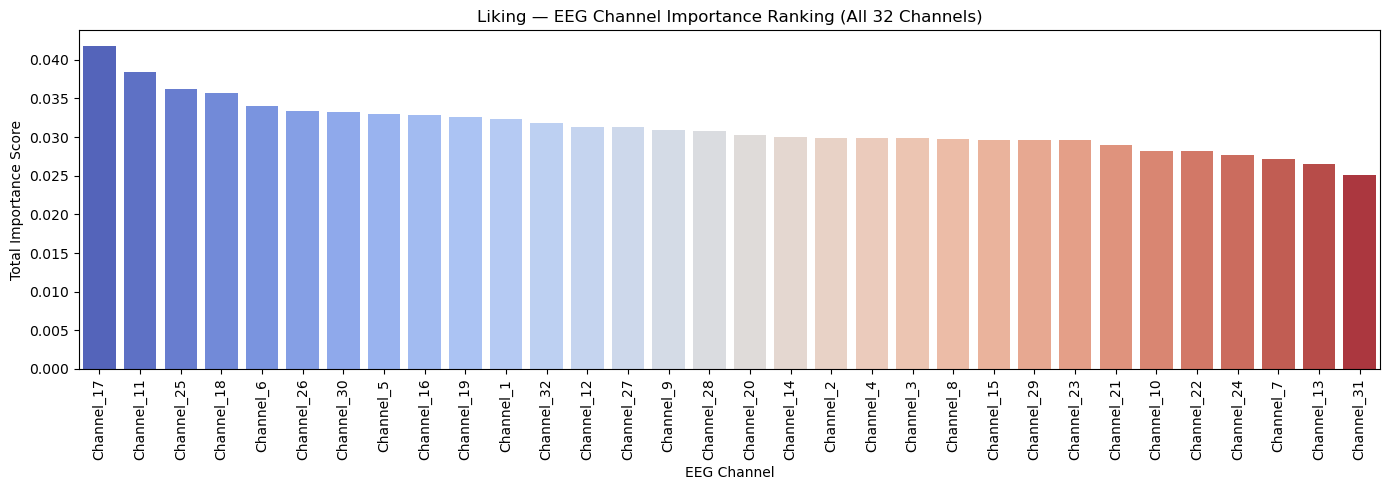


  Liking — Top 32 Channels
  Accuracy  : 0.6719
  Precision : 0.6886
  Recall    : 0.9235
  F1-Score  : 0.7889
  CV Accuracy: 0.6391 ± 0.0132

  Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.54      0.17      0.26        86
 High Liking       0.69      0.92      0.79       170

    accuracy                           0.67       256
   macro avg       0.61      0.55      0.53       256
weighted avg       0.64      0.67      0.61       256


  Liking — Top 16 Channels
  Accuracy  : 0.6562
  Precision : 0.6814
  Recall    : 0.9059
  F1-Score  : 0.7778
  CV Accuracy: 0.6633 ± 0.0129

  Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.47      0.16      0.24        86
 High Liking       0.68      0.91      0.78       170

    accuracy                           0.66       256
   macro avg       0.57      0.53      0.51       256
weighted avg       0.61      0.66      0.60       256


  Likin

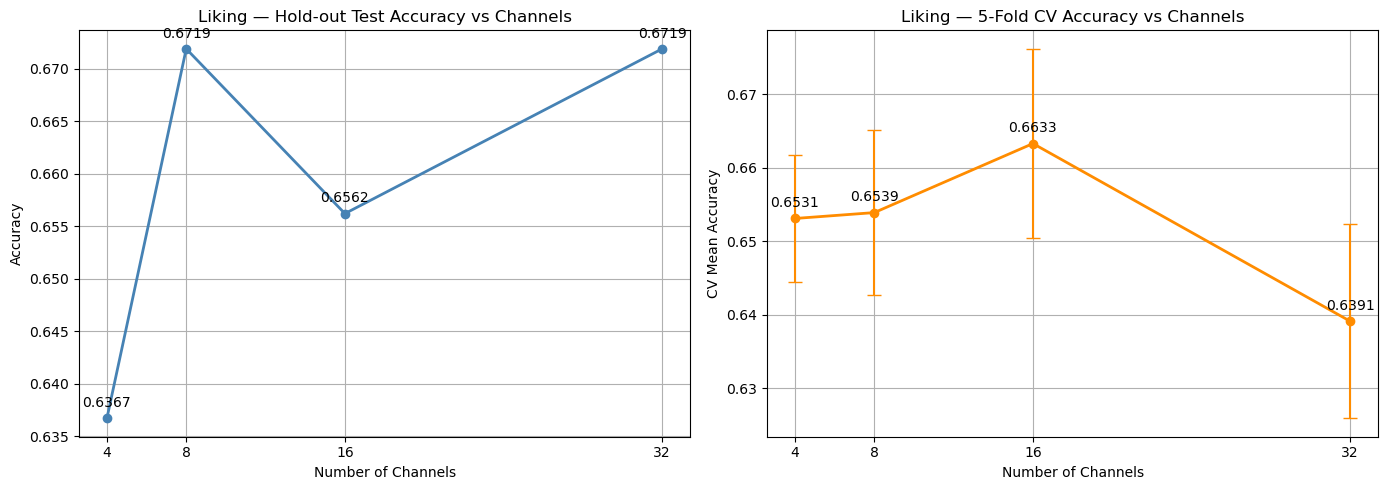

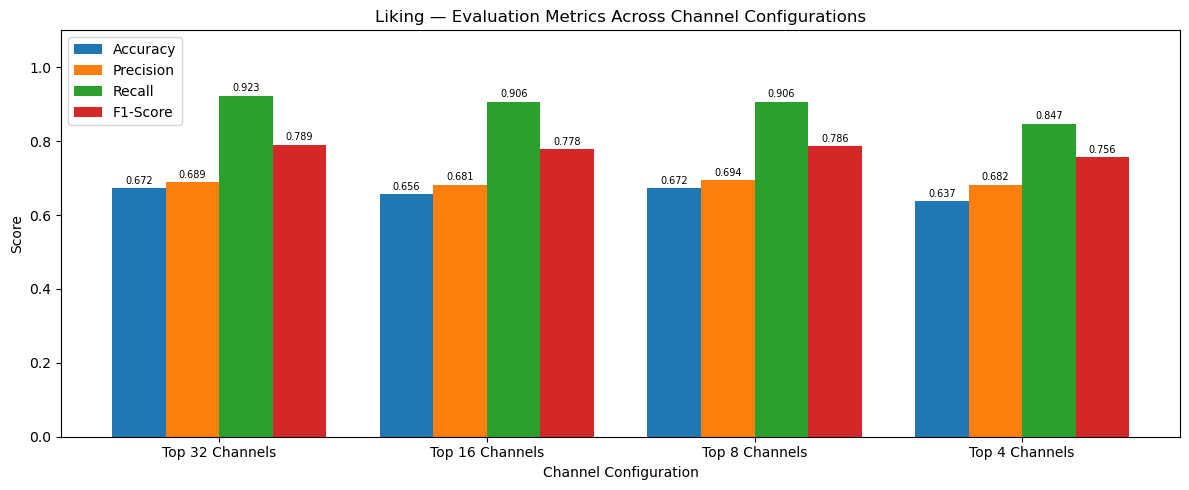

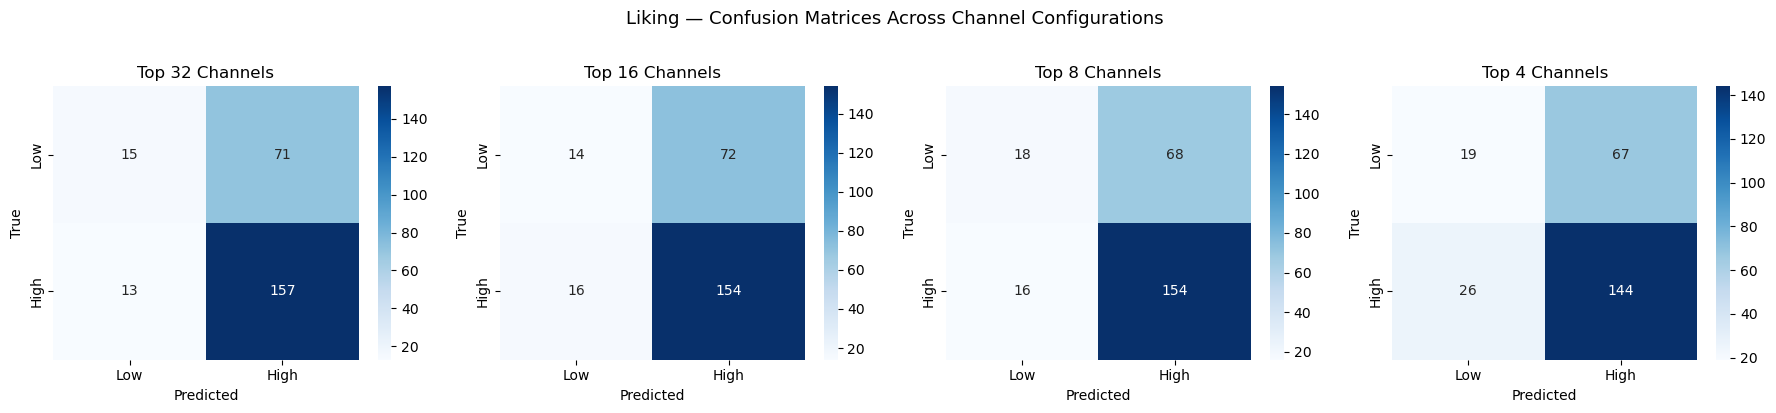


Best configuration for Liking: Top 16 Channels
CV Mean Accuracy : 0.6633 ± 0.0129
Saved → liking_mean_var_model.pkl
Saved → liking_mean_var_scaler.pkl
Selected channels (16): [17, 11, 25, 18, 6, 26, 30, 5, 16, 19, 1, 32, 12, 27, 9, 28]

All four emotions processed.


In [12]:
all_results = []
all_full_model_stats = []
best_model_info = []

for emotion_name in emotion_names:
    y = y_dict[emotion_name]

    full_stats = train_evaluate_full_model(emotion_name, X, y)
    all_full_model_stats.append({"Emotion": emotion_name, **{
        k: v for k, v in full_stats.items() if k not in ("model", "scaler", "channel_ranking")
    }})

    results, results_df, configs, trained = channel_reduction_pipeline(
        emotion_name, eeg, y, full_stats["channel_ranking"]
    )
    all_results.extend(results)

    info = save_best_model(emotion_name, results, configs, trained)
    best_model_info.append(info)

print("\nAll four emotions processed.")

In [13]:
summary_df = pd.DataFrame(all_results)[
    ["Emotion", "Configuration", "Channels", "Features",
     "Accuracy", "Precision", "Recall", "F1-Score", "CV Mean Acc", "CV Std"]
].rename(columns={
    "Configuration": "Channel Set",
    "Features": "Number of Features",
    "CV Mean Acc": "CV Mean",
    "CV Std": "CV Standard Deviation",
})

print("=== Summary: Accuracy/CV per Emotion per Channel Configuration ===")
print(summary_df.to_string(index=False))

best_summary_df = pd.DataFrame(best_model_info)
print("\n=== Best Model per Emotion ===")
print(best_summary_df[["Emotion", "Best Configuration", "Channels",
                        "Model Path", "Scaler Path"]].to_string(index=False))

=== Summary: Accuracy/CV per Emotion per Channel Configuration ===
  Emotion     Channel Set  Channels  Number of Features  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Standard Deviation
  Valence Top 32 Channels        32                  96    0.5859     0.6047  0.7324    0.6624   0.5953                 0.0163
  Valence Top 16 Channels        16                  48    0.5781     0.6012  0.7113    0.6516   0.6039                 0.0179
  Valence  Top 8 Channels         8                  24    0.5898     0.6095  0.7254    0.6624   0.5852                 0.0258
  Valence  Top 4 Channels         4                  12    0.5352     0.5706  0.6549    0.6098   0.5586                 0.0158
  Arousal Top 32 Channels        32                  96    0.5586     0.6062  0.6599    0.6319   0.6148                 0.0403
  Arousal Top 16 Channels        16                  48    0.5703     0.6135  0.6803    0.6452   0.6109                 0.0245
  Arousal  Top 8 Channels         8         

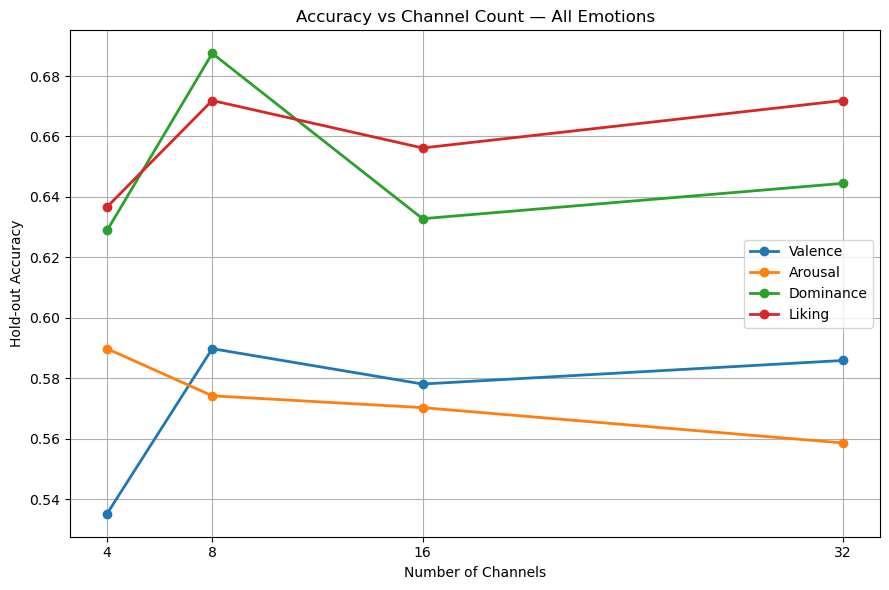

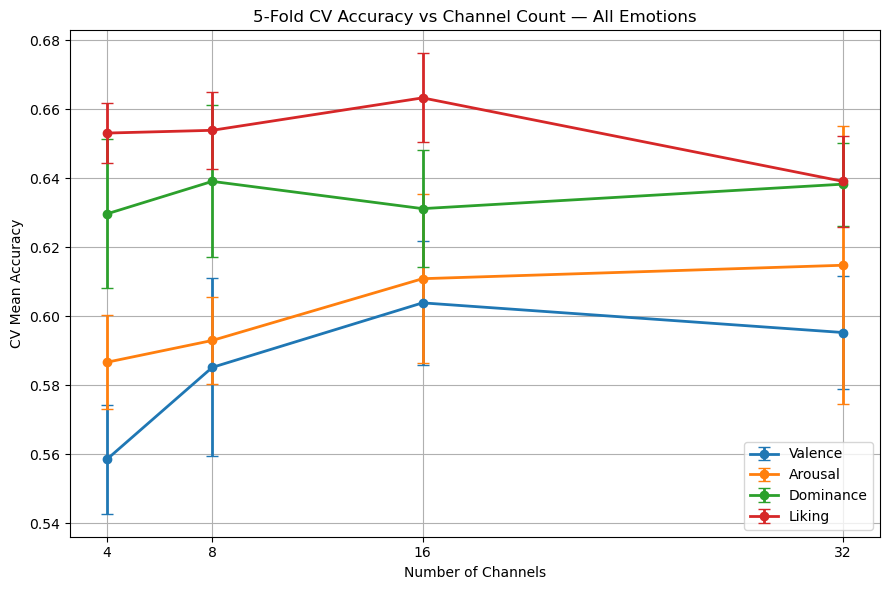

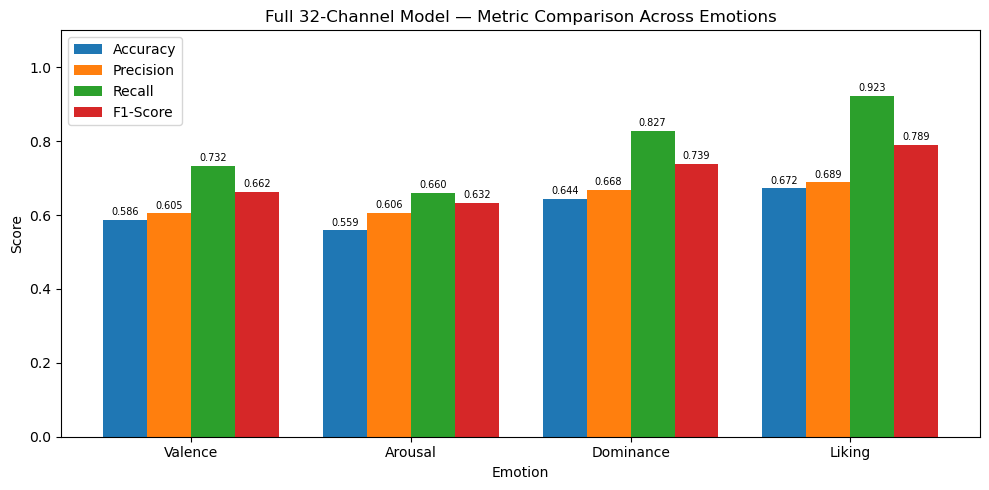

In [14]:
plt.figure(figsize=(9, 6))
for emotion_name in emotion_names:
    sub = summary_df[summary_df["Emotion"] == emotion_name].sort_values("Channels")
    plt.plot(sub["Channels"], sub["Accuracy"], marker="o", linewidth=2, label=emotion_name)
plt.xlabel("Number of Channels")
plt.ylabel("Hold-out Accuracy")
plt.title("Accuracy vs Channel Count — All Emotions")
plt.xticks(sorted(summary_df["Channels"].unique()))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comparison_accuracy_vs_channels_all_emotions.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 6))
for emotion_name in emotion_names:
    sub = summary_df[summary_df["Emotion"] == emotion_name].sort_values("Channels")
    plt.errorbar(sub["Channels"], sub["CV Mean"], yerr=sub["CV Standard Deviation"],
                 marker="o", capsize=4, linewidth=2, label=emotion_name)
plt.xlabel("Number of Channels")
plt.ylabel("CV Mean Accuracy")
plt.title("5-Fold CV Accuracy vs Channel Count — All Emotions")
plt.xticks(sorted(summary_df["Channels"].unique()))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comparison_cv_accuracy_vs_channels_all_emotions.png", dpi=150)
plt.show()

best_per_emotion = summary_df[summary_df["Channel Set"] == "Top 32 Channels"]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(emotion_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics):
    values = [best_per_emotion[best_per_emotion["Emotion"] == e][metric].values[0]
              for e in emotion_names]
    bars = ax.bar(x + i * width, values, width, label=metric)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)
ax.set_xlabel("Emotion")
ax.set_ylabel("Score")
ax.set_title("Full 32-Channel Model — Metric Comparison Across Emotions")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(emotion_names)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig("comparison_metrics_all_emotions.png", dpi=150)
plt.show()